In [1]:
# -----------------------------------------------------------------------------------------
# CELL 1: LOAD AND VALIDATE US-DOMESTIC METRO DATA
# -----------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = None

# 1. Path to the new Metro-mapped US Domestic data
METRO_PATH = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"

# 2. Load the dataset
print("🚀 Loading US-Domestic Metro mission data...")
df = pd.read_parquet(METRO_PATH)

# 3. Terminology Standardization
# If the pipeline left 'FromCluster' or 'ToCluster', we rename them here to 'Metro'
# to ensure the entire notebook follows the new naming convention.
rename_map = {
    'FromCluster': 'FromMetro',
    'ToCluster': 'ToMetro'
}
df = df.rename(columns=rename_map)

# 4. Feature Integrity Check
# Ensure FlightDate_ET is datetime and extract TOD/DOW if missing
df['FlightDate_ET'] = pd.to_datetime(df['FlightDate_ET'])

if 'hour' not in df.columns:
    df['hour'] = df['FlightDate_ET'].dt.hour

# We use 'day_name' for plotting labels
df['day_name'] = df['FlightDate_ET'].dt.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=days, ordered=True)

# --- VALIDATION ---
print(f"✅ Data Loaded: {len(df):,}")
print(f"✅ US-Domestic Check: {df['FromAirport'].str.startswith('K').all()} (All starts with K)")
print(f"✅ Terminology Check: {'FromMetro' in df.columns} (Metro columns present)")

display(df[['FlightDate_ET', 'aircraft_segment', 'FromAirport', 'FromMetro', 'ToAirport', 'ToMetro']].head(5))

🚀 Loading US-Domestic Metro mission data...
✅ Data Loaded: 2,140,706
✅ US-Domestic Check: True (All starts with K)
✅ Terminology Check: True (Metro columns present)


,FlightDate_ET,aircraft_segment,FromAirport,FromMetro,ToAirport,ToMetro
0,2024-03-10 14:37:00-04:00,Super Midsize Jet,KTEX,Denver,KBJC,Denver
1,2024-03-16 18:58:00-04:00,Super Midsize Jet,KJAC,Denver,KSDL,Phoenix Valley
2,2024-03-01 17:32:00-05:00,Super Midsize Jet,KORL,North Florida,KCHO,DMV
3,2024-03-20 12:09:00-04:00,Super Midsize Jet,KFCM,Minneapolis,KSDL,Phoenix Valley
4,2024-03-22 14:12:00-04:00,Super Midsize Jet,KSNA,LA Basin,KSLC,Denver


In [4]:
# -----------------------------------------------------------------------------------------
# CELL 1.5: AIRCRAFT MODEL AUDIT
# LOGIC: Identify all distinct models in the LJ segment to verify filter strings.
# -----------------------------------------------------------------------------------------

# 1. Filter the master dataframe for Light Jets
df_lj_models = df[df['aircraft_segment'] == 'Light Jet']

# 2. Get unique models and their mission counts (to identify the big players)
model_audit = df_lj_models['aircraft_model'].value_counts().reset_index()
model_audit.columns = ['wingx_model_name', 'mission_count']

print(f"📋 DISTINCT LIGHT JET MODELS IN DATASET ({len(model_audit)} found):")
print("-" * 50)
display(model_audit)

# 3. Quick Check for your requested fleet:
requested = ['Phenom 300', 'Citation CJ', 'Hawker 400', 'Beechjet', 'Encore', 'Ultra']
print("\n🔍 PROBABLE MATCHES FOR YOUR FLEET LIST:")
for r in requested:
    matches = model_audit[model_audit['wingx_model_name'].str.contains(r, case=False, na=False)]
    if not matches.empty:
        print(f"Found for '{r}': {matches['wingx_model_name'].tolist()}")

📋 DISTINCT LIGHT JET MODELS IN DATASET (47 found):
--------------------------------------------------


,wingx_model_name,mission_count
0,Phenom 300,266482
1,Citation CJ3,96566
2,no model available,89182
3,Phenom 300-E,63922
4,Citation CJ3+,58531
5,Citation CJ4,52932
6,Citation Ultra,38190
7,400-A,36922
8,Citation V,36508
9,400-XP,31044



🔍 PROBABLE MATCHES FOR YOUR FLEET LIST:
Found for 'Phenom 300': ['Phenom 300', 'Phenom 300-E']
Found for 'Citation CJ': ['Citation CJ3', 'Citation CJ3+', 'Citation CJ4', 'Citation CJ2', 'Citation CJ2+', 'Citation CJ4 Gen2']
Found for 'Hawker 400': ['Hawker 400XP']
Found for 'Encore': ['Citation Encore', 'Citation Encore+']
Found for 'Ultra': ['Citation Ultra']


In [5]:
# -----------------------------------------------------------------------------------------
# CELL 2: PREFERRED FLEET LIGHT JET ANALYSIS
# FILTERING: 
#   1. Segment: Light Jet
#   2. Models: Hardcoded array based on Cell 1.5 audit (Phenom 300, CJ Series, Hawker, etc.)
#   3. Market: US-Domestic (K-to-K), Hours >= 0.5
# -----------------------------------------------------------------------------------------

# 1. Hardcoded array of verified WingX model names from Cell 1.5
target_models = [
    'Phenom 300', 'Phenom 300-E', 
    'Citation CJ3', 'Citation CJ3+', 'Citation CJ4', 'Citation CJ4 Gen2', 
    'Citation CJ2', 'Citation CJ2+',
    'Hawker 400XP', '400-A', '400-XP', 'Beechjet 400',
    'Citation Ultra', 'Citation V', 'Citation Encore', 'Citation Encore+'
]

# 2. Filter the master dataframe
# We calculate the 'shrinkage' by comparing against the total LJ volume (1,084,992)
total_lj_all_models = len(df[df['aircraft_segment'] == 'Light Jet'])

df_lj_raw = df[
    (df['aircraft_segment'] == 'Light Jet') & 
    (df['aircraft_model'].isin(target_models))
].copy()

# 3. Create Corridor Key and Aggregate
df_lj_raw['corridor'] = df_lj_raw['FromMetro'] + " ➔ " + df_lj_raw['ToMetro']
corridor_counts_raw = df_lj_raw['corridor'].value_counts().reset_index()
corridor_counts_raw.columns = ['corridor', 'mission_count']

# 4. Market Share Calculation
total_fleet_missions = len(df_lj_raw)
fleet_retention_pct = (total_fleet_missions / total_lj_all_models) * 100
corridor_counts_raw['pct_of_fleet_market'] = (corridor_counts_raw['mission_count'] / total_fleet_missions) * 100
corridor_counts_raw['cumulative_pct'] = corridor_counts_raw['pct_of_fleet_market'].cumsum()

# --- VALIDATION ---
print(f"📊 PREFERRED FLEET ANALYSIS SUMMARY")
print(f"-------------------------------------------")
print(f"Total LJ Missions (All Models):    {total_lj_all_models:,}")
print(f"Total LJ Missions (Target Fleet): {total_fleet_missions:,}")
print(f"Fleet Selection Retention:         {fleet_retention_pct:.1f}%")
print(f"Volume Shrinkage:                 {100 - fleet_retention_pct:.1f}%")

print(f"\n📋 TOP 20 CORRIDORS (Selected Fleet - Gross View):")
display(corridor_counts_raw.head(20))

📊 PREFERRED FLEET ANALYSIS SUMMARY
-------------------------------------------
Total LJ Missions (All Models):    1,084,992
Total LJ Missions (Target Fleet): 806,349
Fleet Selection Retention:         74.3%
Volume Shrinkage:                 25.7%

📋 TOP 20 CORRIDORS (Selected Fleet - Gross View):


,corridor,mission_count,pct_of_fleet_market,cumulative_pct
0,Denver ➔ Denver,12988,1.610717,1.610717
1,LA Basin ➔ Bay Area,12527,1.553546,3.164263
2,Bay Area ➔ LA Basin,12188,1.511504,4.675767
3,LA Basin ➔ LA Basin,11412,1.415268,6.091035
4,Dallas ➔ Dallas,10290,1.276122,7.367157
5,Seattle ➔ Seattle,9527,1.181498,8.548656
6,South Florida ➔ North Florida,9291,1.152231,9.700886
7,North Florida ➔ South Florida,8677,1.076085,10.776971
8,Denver ➔ LA Basin,8124,1.007504,11.784475
9,Dallas ➔ Denver,8087,1.002916,12.787391


In [7]:
# -----------------------------------------------------------------------------------------
# CELL 3: STRUCTURAL FILTERING (INTER-METRO MARKET)
# FILTERING: 
#   1. Segment: Light Jet Only (Carried from Cell 2)
#   2. Valid Metros: Remove 'OTHER_METRO' from both Origin and Destination
#   3. Inter-Metro Only: Remove flights where FromMetro == ToMetro (Structural Repos)
# -----------------------------------------------------------------------------------------

# 1. Start with the refined fleet from Cell 2
# Filter for Inter-Metro missions between recognized hubs
lj_structural = df_lj_raw[
    (df_lj_raw['FromMetro'] != 'OTHER_METRO') & 
    (df_lj_raw['ToMetro'] != 'OTHER_METRO') & 
    (df_lj_raw['FromMetro'] != df_lj_raw['ToMetro'])
].copy()

# 2. Update the Corridor Key
lj_structural['corridor'] = lj_structural['FromMetro'] + " ➔ " + lj_structural['ToMetro']

# 3. Aggregate Mission Counts AND Average Hours
# Using .agg() allows us to calculate both metrics in one pass
struct_counts = lj_structural.groupby('corridor').agg(
    mission_count=('corridor', 'size'),
    avg_hours=('Hours', 'mean')
).reset_index()

# 4. Sort by volume and calculate Market Share stats
struct_counts = struct_counts.sort_values(by='mission_count', ascending=False).reset_index(drop=True)

total_struct_volume = len(lj_structural)
total_fleet_volume = len(df_lj_raw)

struct_counts['pct_of_structural_market'] = (struct_counts['mission_count'] / total_struct_volume) * 100
struct_counts['cumulative_pct'] = struct_counts['pct_of_structural_market'].cumsum()

# --- VALIDATION ---
print(f"✅ STRUCTURAL FILTER COMPLETE (WITH DURATION)")
print(f"-------------------------------------------")
print(f"Fleet Volume (from Cell 2):        {total_fleet_volume:,}")
print(f"Structural Volume (Inter-Metro):   {total_struct_volume:,}")
print(f"Structural Retention:              {(total_struct_volume / total_fleet_volume) * 100:.1f}%")

# Preview the Top 10 with the new Avg Hours column
print(f"\n📋 TOP 10 INTER-METRO CORRIDORS (Pre-Strategic Exclusion):")
# Rounding avg_hours for readability
display(struct_counts.head(10).style.format({'avg_hours': '{:.2f}', 'pct_of_structural_market': '{:.2f}%'}))

✅ STRUCTURAL FILTER COMPLETE (WITH DURATION)
-------------------------------------------
Fleet Volume (from Cell 2):        806,349
Structural Volume (Inter-Metro):   662,074
Structural Retention:              82.1%

📋 TOP 10 INTER-METRO CORRIDORS (Pre-Strategic Exclusion):


,corridor,mission_count,avg_hours,pct_of_structural_market,cumulative_pct
0,LA Basin ➔ Bay Area,12527,1.05,1.89%,1.892085
1,Bay Area ➔ LA Basin,12188,1.03,1.84%,3.732966
2,South Florida ➔ North Florida,9291,0.83,1.40%,5.136284
3,North Florida ➔ South Florida,8677,0.85,1.31%,6.446862
4,Denver ➔ LA Basin,8124,1.88,1.23%,7.673916
5,Dallas ➔ Denver,8087,1.75,1.22%,8.895380
6,San Antonio ➔ Dallas,7958,0.90,1.20%,10.097361
7,Dallas ➔ San Antonio,7765,0.91,1.17%,11.270190
8,LA Basin ➔ Denver,7491,1.68,1.13%,12.401635
9,Denver ➔ Dallas,7148,1.52,1.08%,13.481272


In [8]:
# -----------------------------------------------------------------------------------------
# CELL 4: DURATION FILTERING (>= 2.0 HOURS)
# FILTERING: 
#   1. Segment: Light Jet Only (Carried from Cell 3)
#   2. Inter-Metro: Already excludes 'OTHER' and Intra-Metro hops
#   3. Duration: MINIMUM 2.0 Hours
# -----------------------------------------------------------------------------------------

# 1. Apply the 2-hour floor to the structural dataset from Cell 3
lj_long_haul = lj_structural[lj_structural['Hours'] >= 2.0].copy()

# 2. Aggregate Mission Counts AND Average Hours for this subset
duration_counts = lj_long_haul.groupby('corridor').agg(
    mission_count=('corridor', 'size'),
    avg_hours=('Hours', 'mean')
).reset_index()

# 3. Sort by volume and calculate Market Share stats
duration_counts = duration_counts.sort_values(by='mission_count', ascending=False).reset_index(drop=True)

total_struct_volume = len(lj_structural) # Volume from Cell 3
total_long_haul_volume = len(lj_long_haul) # Volume after this filter

retention_from_struct = (total_long_haul_volume / total_struct_volume) * 100
duration_counts['pct_of_long_haul_market'] = (duration_counts['mission_count'] / total_long_haul_volume) * 100
duration_counts['cumulative_pct'] = duration_counts['pct_of_long_haul_market'].cumsum()

# --- VALIDATION ---
print(f"✅ DURATION FILTER COMPLETE (>= 2.0 HOURS)")
print(f"-------------------------------------------")
print(f"Structural Volume (from Cell 3):   {total_struct_volume:,}")
print(f"Long-Haul Volume (>= 2.0 hrs):     {total_long_haul_volume:,}")
print(f"Duration Retention:                {retention_from_struct:.1f}%")
print(f"Duration Shrinkage:               {100 - retention_from_struct:.1f}%")
print(f"Total Cumulative Shrinkage (vs Raw): {100 - (total_long_haul_volume / total_lj_all_models * 100):.1f}%")

# Preview the Top 10 Long-Haul Corridors
print(f"\n📋 TOP 10 LONG-HAUL CORRIDORS (Pre-Strategic Exclusion):")
display(duration_counts.head(10).style.format({'avg_hours': '{:.2f}', 'pct_of_long_haul_market': '{:.2f}%'}))

✅ DURATION FILTER COMPLETE (>= 2.0 HOURS)
-------------------------------------------
Structural Volume (from Cell 3):   662,074
Long-Haul Volume (>= 2.0 hrs):     185,776
Duration Retention:                28.1%
Duration Shrinkage:               71.9%
Total Cumulative Shrinkage (vs Raw): 82.9%

📋 TOP 10 LONG-HAUL CORRIDORS (Pre-Strategic Exclusion):


,corridor,mission_count,avg_hours,pct_of_long_haul_market,cumulative_pct
0,South Florida ➔ New York City,3935,2.71,2.12%,2.118142
1,New York City ➔ South Florida,3799,2.87,2.04%,4.163078
2,Chicago ➔ South Florida,3468,2.68,1.87%,6.029842
3,South Florida ➔ Chicago,3436,2.85,1.85%,7.879382
4,Denver ➔ LA Basin,3182,2.30,1.71%,9.592197
5,Dallas ➔ LA Basin,2640,2.91,1.42%,11.013263
6,Seattle ➔ LA Basin,2620,2.33,1.41%,12.423564
7,Chicago ➔ Denver,2563,2.67,1.38%,13.803182
8,Dallas ➔ Denver,2542,2.41,1.37%,15.171497
9,LA Basin ➔ Seattle,2382,2.38,1.28%,16.453686


In [9]:
# -----------------------------------------------------------------------------------------
# CELL 5: MARKET SHARE & WUP PRESENCE ANALYSIS
# FILTERING: 
#   1. Segment: Light Jet (Fleet Verified)
#   2. Market: Inter-Metro, Long-Haul (>= 2.0 Hours)
#   3. WUP Definition: Operator contains 'Wheels Up' OR == 'Mountain Aviation'
# -----------------------------------------------------------------------------------------

# 1. Define WUP Presence in the Long-Haul Dataset
# We use a case-insensitive search for 'Wheels Up' and an exact match for 'Mountain Aviation'
wup_mask = (
    (lj_long_haul['Operator'].str.contains('Wheels Up', case=False, na=False)) | 
    (lj_long_haul['Operator'] == 'Mountain Aviation')
)
lj_long_haul['is_wup'] = wup_mask

# 2. Aggregate Market Data and WUP Data side-by-side
# We group by corridor to get Total Market Volume, Avg Hours, and WUP-specific volume
master_strat = lj_long_haul.groupby('corridor').agg(
    market_missions=('corridor', 'size'),
    avg_hours=('Hours', 'mean'),
    wup_missions=('is_wup', 'sum')
).reset_index()

# 3. Calculate WUP Share Percentage
master_strat['wup_share_pct'] = (master_strat['wup_missions'] / master_strat['market_missions']) * 100

# 4. Sort by Total Market Volume to see the biggest opportunities
master_strat = master_strat.sort_values(by='market_missions', ascending=False).reset_index(drop=True)

# --- VALIDATION STATS ---
total_long_haul = len(lj_long_haul)
total_wup_missions = lj_long_haul['is_wup'].sum()
overall_wup_share = (total_wup_missions / total_long_haul) * 100

print(f"🎯 WUP STRATEGIC PRESENCE REPORT")
print(f"-------------------------------------------")
print(f"Total Market Long-Haul Missions: {total_long_haul:,}")
print(f"Total WUP Long-Haul Missions:    {total_wup_missions:,}")
print(f"Overall WUP Market Share:        {overall_wup_share:.1f}%")

# Display the Top 20 Corridors with WUP Share
print(f"\n📋 STRATEGIC MASTER TABLE (Top 20 by Market Volume):")
display(master_strat.head(20).style.format({
    'avg_hours': '{:.2f}', 
    'wup_share_pct': '{:.1f}%',
    'market_missions': '{:,}',
    'wup_missions': '{:,}'
}))

🎯 WUP STRATEGIC PRESENCE REPORT
-------------------------------------------
Total Market Long-Haul Missions: 185,776
Total WUP Long-Haul Missions:    6,696
Overall WUP Market Share:        3.6%

📋 STRATEGIC MASTER TABLE (Top 20 by Market Volume):


,corridor,market_missions,avg_hours,wup_missions,wup_share_pct
0,South Florida ➔ New York City,"3,935",2.71,150,3.8%
1,New York City ➔ South Florida,"3,799",2.87,110,2.9%
2,Chicago ➔ South Florida,"3,468",2.68,105,3.0%
3,South Florida ➔ Chicago,"3,436",2.85,111,3.2%
4,Denver ➔ LA Basin,"3,182",2.30,93,2.9%
5,Dallas ➔ LA Basin,"2,640",2.91,28,1.1%
6,Seattle ➔ LA Basin,"2,620",2.33,62,2.4%
7,Chicago ➔ Denver,"2,563",2.67,64,2.5%
8,Dallas ➔ Denver,"2,542",2.41,72,2.8%
9,LA Basin ➔ Seattle,"2,382",2.38,53,2.2%


In [13]:
# -----------------------------------------------------------------------------------------
# CELL 6: STRATEGIC RHOMBUS & PAIR-SPECIFIC EXCLUSIONS
# -----------------------------------------------------------------------------------------

# 1. Define the Metro-level exclusions (California)
metro_exclusions = ['LA Basin', 'Bay Area']

# 2. Define specific Corridor-level exclusions (The Medical Corridor)
# We use exact strings to ensure we don't accidentally kill Houston ➔ Florida
pair_exclusions = ['Dallas ➔ Houston', 'Houston ➔ Dallas']

# 3. Apply Metro-level exclusions first (Regex)
exclude_pattern = '|'.join(metro_exclusions)
master_rhombus = master_strat[
    ~master_strat['corridor'].str.contains(exclude_pattern, case=False, na=False)
].copy()

# 4. Apply Pair-specific exclusions
master_rhombus = master_rhombus[
    ~master_rhombus['corridor'].isin(pair_exclusions)
].copy()

# 5. Re-calculate the Top 20 for this refined Rhombus
master_rhombus = master_rhombus.sort_values(by='market_missions', ascending=False).head(20).reset_index(drop=True)

# --- VALIDATION ---
print(f"🛡️ REFINED STRATEGIC RHOMBUS")
print(f"-------------------------------------------")
print(f"Corridors remaining: {len(master_rhombus):,} (Top 20 Isolate)")
print(f"Check: 'Houston ➔ Dallas' in list? {master_rhombus['corridor'].isin(['Houston ➔ Dallas']).any()}")

# Display the Final Strategic Table
print(f"\n📋 FINAL STRATEGIC TOP 20 (The 'Rhombus' Targets):")
display(master_rhombus.style.format({
    'avg_hours': '{:.2f}', 
    'wup_share_pct': '{:.1f}%',
    'market_missions': '{:,}',
    'wup_missions': '{:,}'
}))

🛡️ REFINED STRATEGIC RHOMBUS
-------------------------------------------
Corridors remaining: 20 (Top 20 Isolate)
Check: 'Houston ➔ Dallas' in list? False

📋 FINAL STRATEGIC TOP 20 (The 'Rhombus' Targets):


,corridor,market_missions,avg_hours,wup_missions,wup_share_pct
0,South Florida ➔ New York City,"3,935",2.71,150,3.8%
1,New York City ➔ South Florida,"3,799",2.87,110,2.9%
2,Chicago ➔ South Florida,"3,468",2.68,105,3.0%
3,South Florida ➔ Chicago,"3,436",2.85,111,3.2%
4,Chicago ➔ Denver,"2,563",2.67,64,2.5%
5,Dallas ➔ Denver,"2,542",2.41,72,2.8%
6,South Florida ➔ Dallas,"2,331",3.02,41,1.8%
7,DMV ➔ South Florida,"2,233",2.38,222,9.9%
8,South Florida ➔ Detroit,"2,221",2.61,156,7.0%
9,Detroit ➔ South Florida,"2,180",2.59,147,6.7%


In [14]:
# -----------------------------------------------------------------------------------------
# CELL 7: PREPARE DOW HEATMAP DATA
# -----------------------------------------------------------------------------------------

# 1. Get the list of the Top 20 Rhombus corridors from Cell 6
target_corridors = master_rhombus['corridor'].tolist()

# 2. Filter the long-haul dataset to just these 20
df_heatmap = lj_long_haul[lj_long_haul['corridor'].isin(target_corridors)].copy()

# 3. Aggregate by Corridor and Day of Week
# Note: 'day_name' was categorical-sorted in Cell 1
dow_market = df_heatmap.groupby(['corridor', 'day_name'], observed=False).size().unstack(fill_value=0)

# 4. Aggregate WUP specific volume for share analysis
dow_wup = df_heatmap[df_heatmap['is_wup'] == True].groupby(['corridor', 'day_name'], observed=False).size().unstack(fill_value=0)

# 5. Calculate WUP Share % per Day per Corridor
# (WUP Missions / Market Missions)
dow_share = (dow_wup / dow_market * 100).fillna(0)

# Re-order the index to match the ranking in master_rhombus (highest volume at top)
dow_market = dow_market.reindex(target_corridors)
dow_share = dow_share.reindex(target_corridors)

# --- VALIDATION ---
print(f"✅ Heatmap Data Ready")
print(f"📊 Analyzing {len(df_heatmap):,} missions across {len(target_corridors)} corridors.")

✅ Heatmap Data Ready
📊 Analyzing 46,964 missions across 20 corridors.


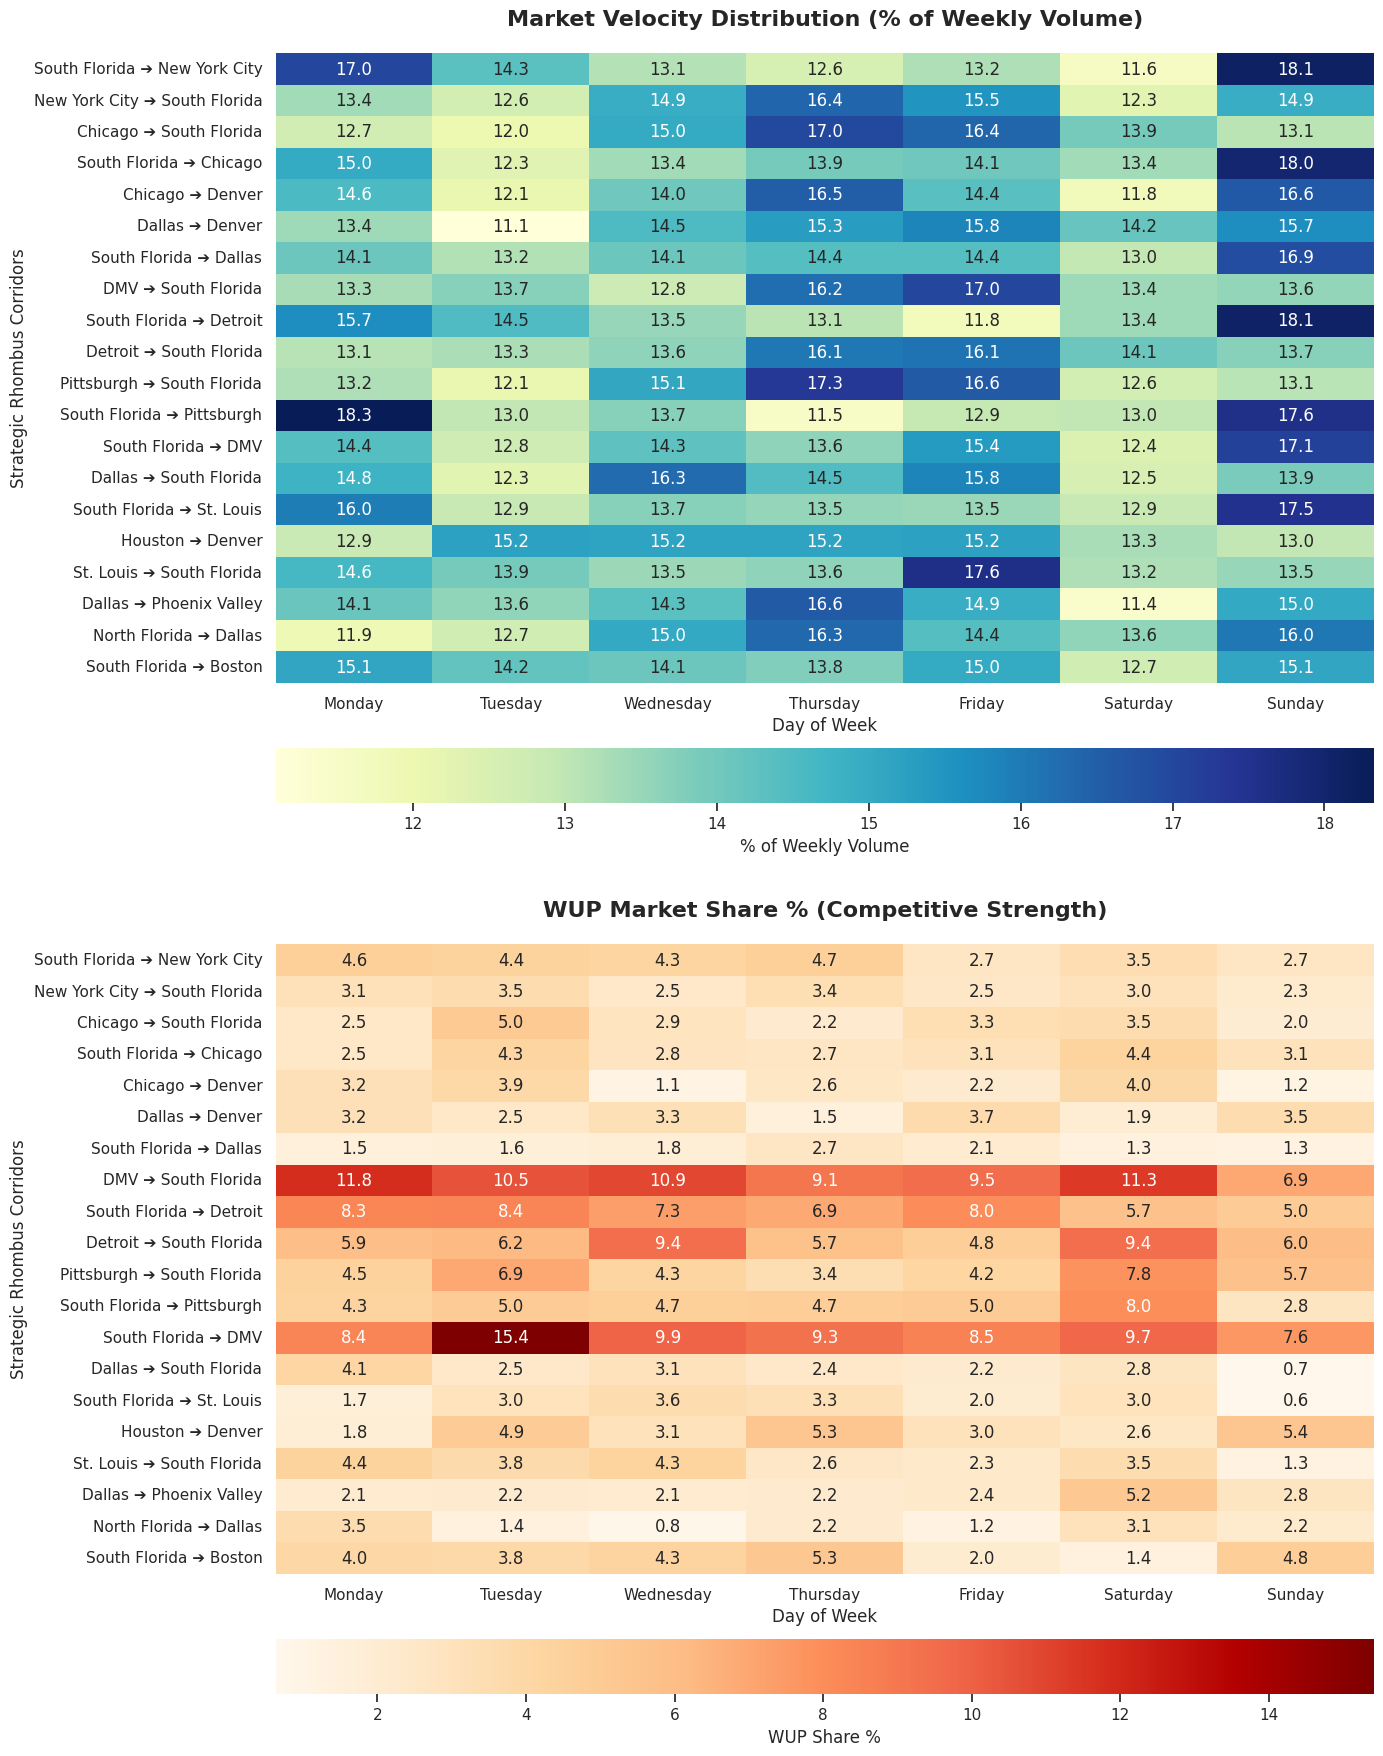

💡 PREMIUM EXTRACTION AUDIT:
Compare the peaks in the top chart (Market Velocity) to the strength in the bottom chart (WUP Share).
High-velocity peaks with high WUP share are your primary 'Premium Toggle' candidates.


In [17]:
# -----------------------------------------------------------------------------------------
# CELL 8: STACKED DOW STRATEGIC HEATMAPS
# -----------------------------------------------------------------------------------------

# 1. Normalize the Market Volume to see % of weekly flow per corridor
dow_market_pct = dow_market.div(dow_market.sum(axis=1), axis=0) * 100

# Create a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# --- 1. MARKET TEMPORAL DISTRIBUTION (% of Weekly Total) ---
sns.heatmap(dow_market_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax1, 
            cbar_kws={'label': '% of Weekly Volume', 'orientation': 'horizontal', 'pad': 0.08})
ax1.set_title("Market Velocity Distribution (% of Weekly Volume)", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Day of Week", fontsize=12)
ax1.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

# --- 2. WUP SHARE HEATMAP (% Market Share) ---
sns.heatmap(dow_share, annot=True, fmt=".1f", cmap="OrRd", ax=ax2, 
            cbar_kws={'label': 'WUP Share %', 'orientation': 'horizontal', 'pad': 0.08})
ax2.set_title("WUP Market Share % (Competitive Strength)", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel("Day of Week", fontsize=12)
ax2.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

plt.tight_layout()
plt.show()

# --- REFINED STRATEGIC SUMMARY ---
print(f"💡 PREMIUM EXTRACTION AUDIT:")
print(f"Compare the peaks in the top chart (Market Velocity) to the strength in the bottom chart (WUP Share).")
print(f"High-velocity peaks with high WUP share are your primary 'Premium Toggle' candidates.")

In [18]:
# -----------------------------------------------------------------------------------------
# CELL 9: PREPARE TOD HEATMAP DATA (RM BUCKETS)
# -----------------------------------------------------------------------------------------

# 1. Define the Revenue Management Time Buckets
def get_rm_bucket(hour):
    if 7 <= hour <= 9:   return '07:00-09:59'
    if 10 <= hour <= 12: return '10:00-12:59'
    if 13 <= hour <= 15: return '13:00-15:59'
    if 16 <= hour <= 18: return '16:00-18:59'
    if 19 <= hour <= 21: return '19:00-21:59'
    return 'Off-Peak (Late/Early)'

# 2. Apply buckets to the heatmap dataframe
df_heatmap['tod_bucket'] = df_heatmap['hour'].apply(get_rm_bucket)

# 3. Ensure logical ordering for the heatmap X-axis
tod_order = ['07:00-09:59', '10:00-12:59', '13:00-15:59', '16:00-18:59', '19:00-21:59', 'Off-Peak (Late/Early)']
df_heatmap['tod_bucket'] = pd.Categorical(df_heatmap['tod_bucket'], categories=tod_order, ordered=True)

# 4. Aggregate Market TOD Volume
tod_market = df_heatmap.groupby(['corridor', 'tod_bucket'], observed=False).size().unstack(fill_value=0)
tod_market_pct = tod_market.div(tod_market.sum(axis=1), axis=0) * 100

# 5. Aggregate WUP TOD Volume for Share %
tod_wup = df_heatmap[df_heatmap['is_wup'] == True].groupby(['corridor', 'tod_bucket'], observed=False).size().unstack(fill_value=0)
tod_share = (tod_wup / tod_market * 100).fillna(0)

# 6. Re-index to maintain Top 20 ranking
tod_market_pct = tod_market_pct.reindex(target_corridors)
tod_share = tod_share.reindex(target_corridors)

print(f"✅ TOD Heatmap Data Ready using RM Buckets")

✅ TOD Heatmap Data Ready using RM Buckets


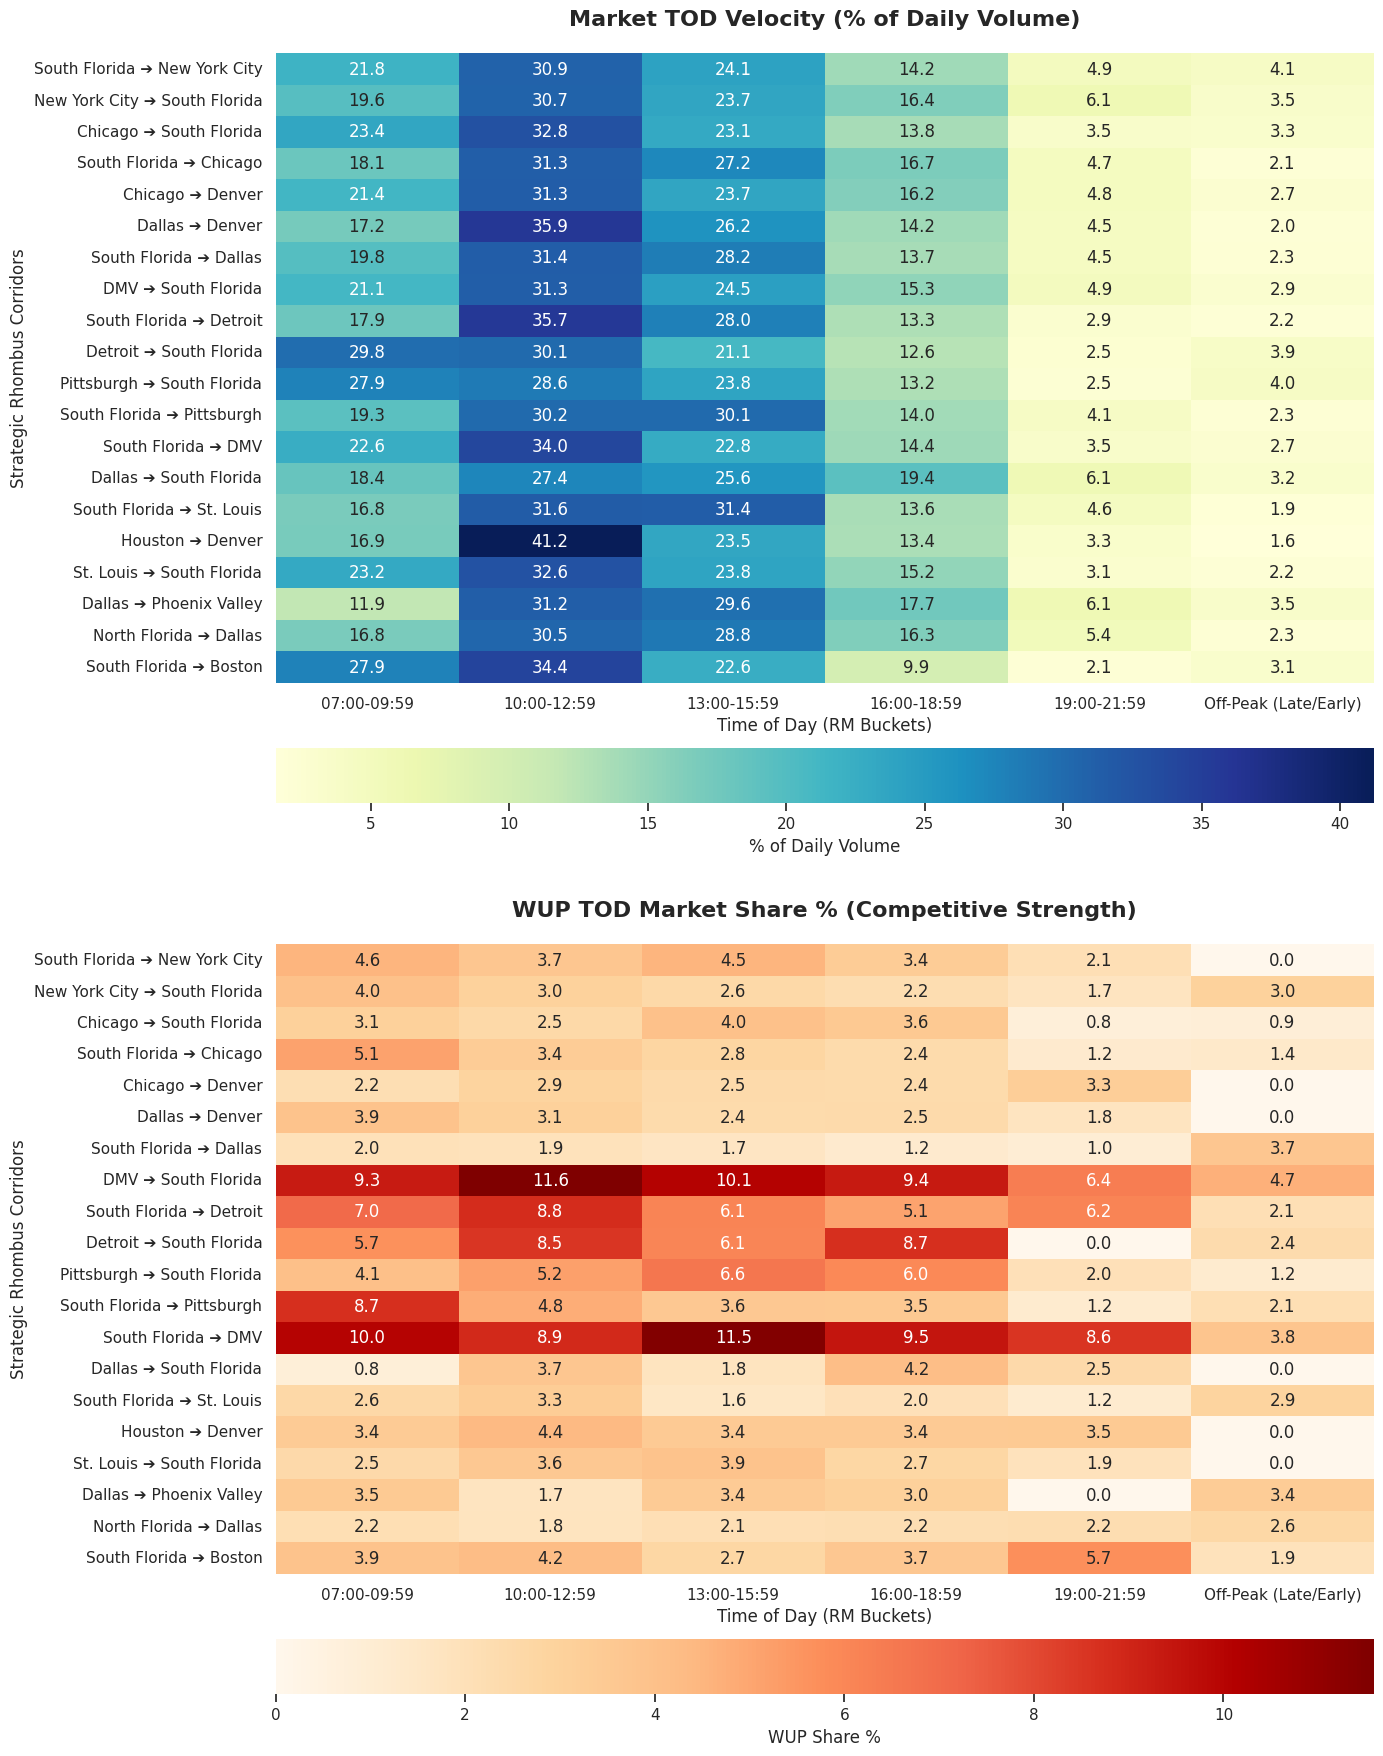

💡 TOD PREMIUM AUDIT:
Identify windows where WUP Share (Bottom) is high during peak Market Velocity (Top).
Example: If 10:00-12:59 is the darkest blue and also dark red, that's your 'Golden Window' for pricing.


In [19]:
# -----------------------------------------------------------------------------------------
# CELL 10: STACKED TOD STRATEGIC HEATMAPS
# -----------------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# --- 1. MARKET TOD DISTRIBUTION (% of Daily Total) ---
sns.heatmap(tod_market_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax1, 
            cbar_kws={'label': '% of Daily Volume', 'orientation': 'horizontal', 'pad': 0.08})
ax1.set_title("Market TOD Velocity (% of Daily Volume)", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Time of Day (RM Buckets)", fontsize=12)
ax1.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

# --- 2. WUP TOD SHARE HEATMAP (% Market Share) ---
sns.heatmap(tod_share, annot=True, fmt=".1f", cmap="OrRd", ax=ax2, 
            cbar_kws={'label': 'WUP Share %', 'orientation': 'horizontal', 'pad': 0.08})
ax2.set_title("WUP TOD Market Share % (Competitive Strength)", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel("Time of Day (RM Buckets)", fontsize=12)
ax2.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

plt.tight_layout()
plt.show()

# --- TOD STRATEGIC SUMMARY ---
print(f"💡 TOD PREMIUM AUDIT:")
print(f"Identify windows where WUP Share (Bottom) is high during peak Market Velocity (Top).")
print(f"Example: If 10:00-12:59 is the darkest blue and also dark red, that's your 'Golden Window' for pricing.")